In [2]:
# Ran with predictors_simple kernel
# Python 3.10.8

import numpy as np # 1.26.4
import pandas as pd # 2.2.3
import tensorflow as tf # 2.10.0
import matplotlib # 3.10.3
import torch # 2.0.0

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.sans-serif'] = 'Arial'

from matplotlib import pyplot as plt
from joblib import load
from scipy.stats import spearmanr, pearsonr, mannwhitneyu
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import auc
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec
import seaborn as sns

import os

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction/Model")
from ADModel_abund import ADModel_abund
from Data import DataReader, SplitData, FastTensorDataLoader, one_hot_encode

os.chdir("/Users/claireleblanc/Documents/tools_software/adhunter")
from actpred.models import ActCNNSystem

# Set Numpy to display floats with 3 decimal places
np.set_printoptions(formatter={'float': lambda x: "{0:0.3f}".format(x)})

os.chdir("/Users/claireleblanc/Documents/grad_school/staller_lab/NN_interpretability_for_AD_prediction")

In [4]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Reading in the full length sequences and tile data

data = pd.read_csv("Data/Unique_502_Gcn4_Seqs_three_clusters.csv", index_col=0)
test_seqs= data[data["heirarchical"] == 1]
val_seqs= data[data["heirarchical"] == 2]
train_seqs = data[data["heirarchical"] == 3]

tile_data = pd.read_csv("Data/pm_gcn4_sort2_pools_allchannels_wrangled.csv")

activity_dict = {}
for i in tile_data.index:
    activity_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"activity"]

abund_dict = {}
for i in tile_data.index:
    abund_dict[tile_data.loc[i,"aa_seq"]] = tile_data.loc[i,"abundance"]

used_tiles = []

def get_tile_activity(tile):
    used_tiles.append(tile)
    return activity_dict.get(tile)

def get_tile_abundance(tile):
    return abund_dict.get(tile)


# Break full length seqs into tiles, adding in the final tile
test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
test_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]
test_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in test_seqs["40_tiles"]]

val_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in val_seqs["Sequence"]]
val_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in val_seqs["Sequence"]]
val_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]
val_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in val_seqs["40_tiles"]]


train_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in train_seqs["Sequence"]]
train_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in train_seqs["Sequence"]]
train_seqs["40_tiles_exp_activities"] = [[get_tile_activity(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]
train_seqs["40_tiles_exp_abundance"] = [[get_tile_abundance(tile) for tile in tiles] for tiles in train_seqs["40_tiles"]]

unused_tiles = list(set(tile_data["aa_seq"]).difference(set(used_tiles)))
other_tiles = pd.DataFrame(unused_tiles, columns=["aa_seq"])
other_tiles["activity"] = [get_tile_activity(s) for s in other_tiles["aa_seq"]]
other_tiles["abundance"] = [get_tile_abundance(s) for s in other_tiles["aa_seq"]]


/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_49416/3253413107.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tiles"] = [[seq[i:i+40] for i in range(0,len(seq)-39,5)] + [seq[-40:]] for seq in test_seqs["Sequence"]]
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_49416/3253413107.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["40_tile_centers"] = [[i+20 for i in range(0,len(seq)-39,5)] + [len(seq)-20] for seq in test_seqs["Sequence"]]
/var/folders/3

In [5]:
# Running ADHunter on the test data
kernel_size = 5
dilation = 3 
hidden = 64

# Loading the ADHunter-mCherry model
mcherry_model = ActCNNSystem(hidden, kernel_size, dilation, num_res_blocks=3)
mcherry_model.load_state_dict(torch.load("../../../tools_software/adhunter/adhunter_cherry_v2.pt"))
mcherry_model.eval()

sc_mcherry=load('../../../tools_software/adhunter/scaler_cherry_v2.pkl')

# Used to encode the input sequence
alphabet="ACDEFGHIKLMNPQRSTVWY"
aa_to_i = {aa:i for i, aa in enumerate(alphabet)}
i_to_aa = {i:aa for i, aa in enumerate(alphabet)}

def run_adhunter(model, sequence, sc):
    """
    Runs ADHunter on an input sequence
    """
    X = np.asarray([[aa_to_i[aa] for aa in sequence]])
    X = torch.tensor(X)
    result = model(X)
    result = sc.inverse_transform(result.detach().numpy().reshape(-1, 1))
    return result[0,0]


# Predict ADHunter score for each 40aa tile in the validation data set
test_seqs["adhunter_mcherry_pred"] = [[run_adhunter(mcherry_model, tile, sc_mcherry) for tile in tiles] for tiles in test_seqs["40_tiles"]]
other_tiles["adhunter_mcherry_pred"] = [run_adhunter(mcherry_model, tile, sc_mcherry) for tile in other_tiles["aa_seq"]]

/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_49416/4166349942.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["adhunter_mcherry_pred"] = [[run_adhunter(mcherry_model, tile, sc_mcherry) for tile in tiles] for tiles in test_seqs["40_tiles"]]


In [6]:
# Running ADHunter on the test data
kernel_size = 5
dilation = 3 
hidden = 64

# Loading the ADHunter-GFP model
gfp_model = ActCNNSystem(hidden, kernel_size, dilation, num_res_blocks=3)
gfp_model.load_state_dict(torch.load("../../../tools_software/adhunter/adhunter_gfp_v2.pt"))
gfp_model.eval()

sc_gfp=load('../../../tools_software/adhunter/scaler_gfp_v2.pkl')

# Used to encode the input sequence
alphabet="ACDEFGHIKLMNPQRSTVWY"
aa_to_i = {aa:i for i, aa in enumerate(alphabet)}
i_to_aa = {i:aa for i, aa in enumerate(alphabet)}

def run_adhunter(model, sequence, sc):
    """
    Runs ADHunter on an input sequence
    """
    X = np.asarray([[aa_to_i[aa] for aa in sequence]])
    X = torch.tensor(X)
    result = model(X)
    result = sc.inverse_transform(result.detach().numpy().reshape(-1, 1))
    return result[0,0]


# Predict ADHunter score for each 40aa tile in the test data set (other tiles are also part of the test data)
test_seqs["adhunter_gfp_pred"] = [[run_adhunter(gfp_model, tile, sc_gfp) for tile in tiles] for tiles in test_seqs["40_tiles"]]
other_tiles["adhunter_gfp_pred"] = [run_adhunter(gfp_model, tile, sc_gfp) for tile in other_tiles["aa_seq"]]

/Users/claireleblanc/miniconda3/envs/predictors_simple/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `SpearmanCorrcoef` will save all targets and predictions in the buffer. For large datasets, this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_49416/3289843460.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_seqs["adhunter_gfp_pred"] = [[run_adhunter(gfp_model, tile, sc_gfp) for tile in tiles] for tiles in test_seqs["40_tiles"]]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


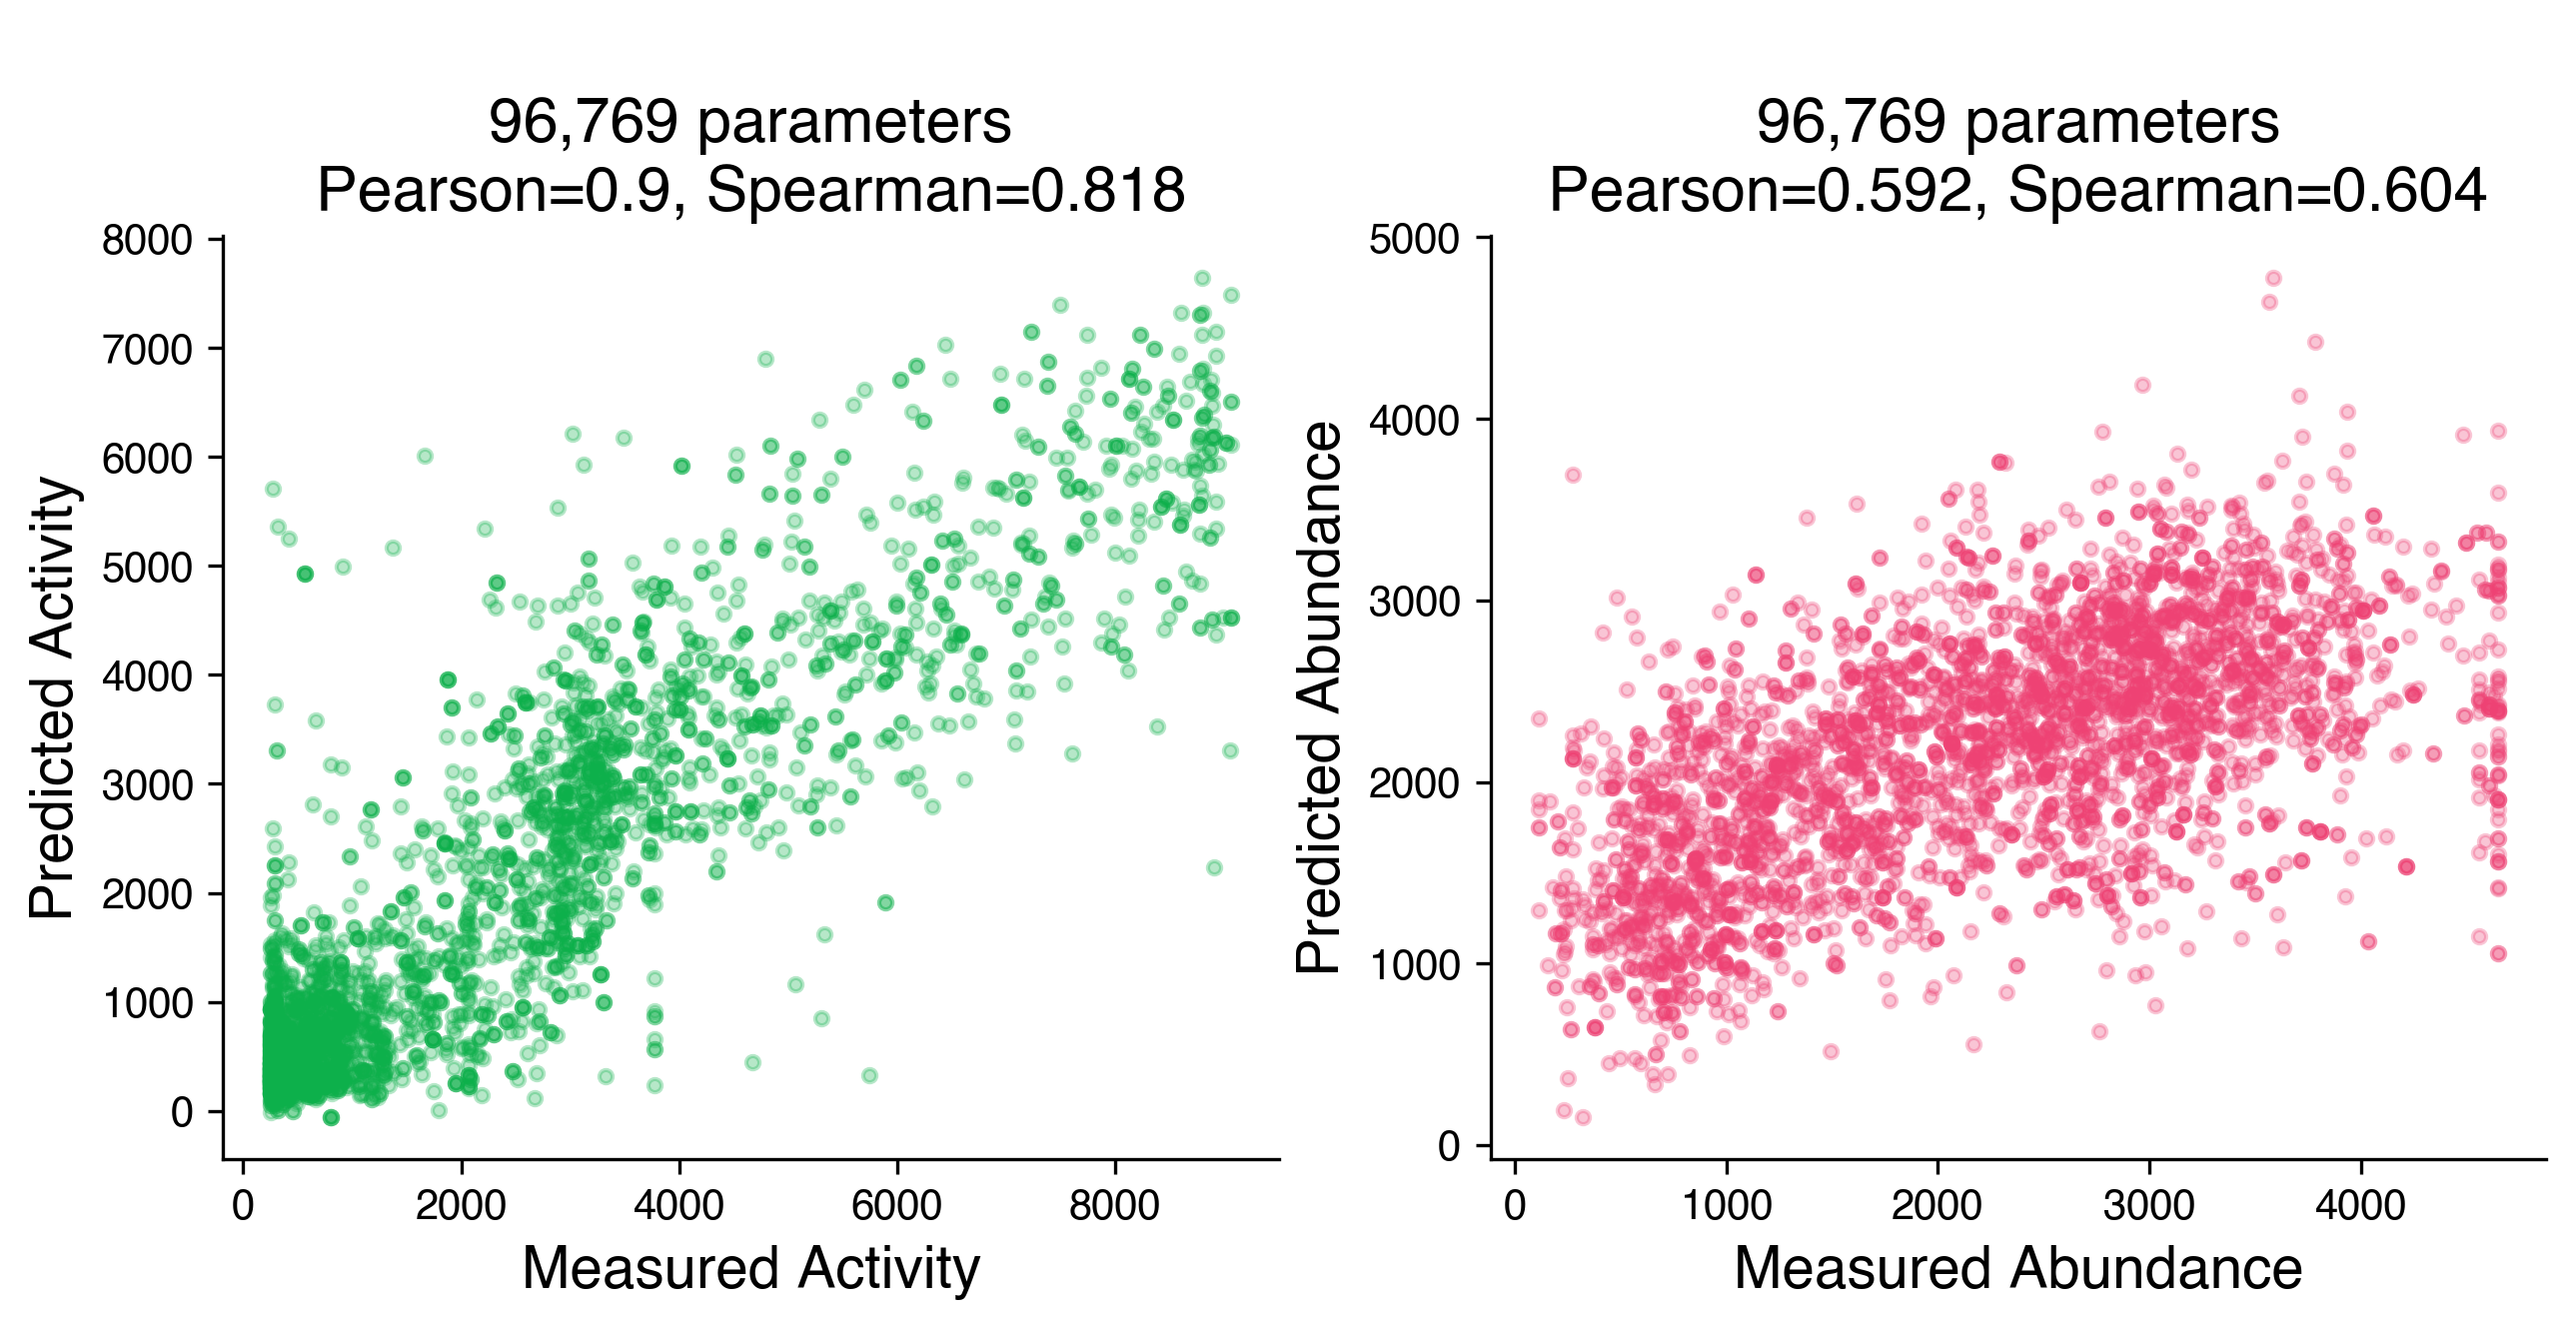

In [8]:
# Code to plot scatter plots for two-state BiophysicalNN, and ADHunter

fig, axs = plt.subplots(1,2,figsize=(10,4))

# Scatter plot for two-state BiophysicalNN - GFP
tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
tiles = tiles + (list(other_tiles["aa_seq"]))
actual = [i for ls in test_seqs["40_tiles_exp_activities"] for i in ls]
actual = actual + (list(other_tiles["activity"]))
pred = [i for ls in test_seqs["adhunter_gfp_pred"] for i in ls]
pred = pred + (list(other_tiles["adhunter_gfp_pred"]))
plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[0].scatter(actual, pred, color='#0DB04B', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[0].set_xlabel('Measured Activity', fontsize=14)
axs[0].set_ylabel('Predicted Activity', fontsize=14)
axs[0].set_title(f'96,769 parameters\nPearson={pearson:.3}, Spearman={spearman:.3}', fontsize=15)

# Scatter plot for two-state BiophysicalNN - mCherry
tiles = [i for ls in test_seqs["40_tiles"] for i in ls]
tiles = tiles + (list(other_tiles["aa_seq"]))
actual = [i for ls in test_seqs["40_tiles_exp_abundance"] for i in ls]
actual = actual + (list(other_tiles["abundance"]))
pred = [i for ls in test_seqs["adhunter_mcherry_pred"] for i in ls]
pred = pred + (list(other_tiles["adhunter_mcherry_pred"]))
plotting_data = pd.DataFrame((actual, pred, tiles)).T
plotting_data = plotting_data.dropna()
plotting_data.columns = ["actual", "pred", "aa_seq"]
plotting_data = plotting_data.drop_duplicates("aa_seq") 

axs[1].scatter(actual, pred, color='#EE4274', s=10, alpha=0.3)
spearman = spearmanr(plotting_data["actual"], plotting_data["pred"]).correlation
pearson = pearsonr(plotting_data["actual"].astype('float'), plotting_data["pred"].astype('float')).correlation#np.corrcoef(list(plotting_data["actual"].values), list(plotting_data["pred"].values))[0, 1] ** 2
axs[1].set_xlabel('Measured Abundance', fontsize=14)
axs[1].set_ylabel('Predicted Abundance', fontsize=14)
axs[1].set_title(f'\n96,769 parameters\nPearson={pearson:.3}, Spearman={spearman:.3}', fontsize=15)

sns.despine()
plt.savefig("/Users/claireleblanc/Documents/grad_school/staller_lab/stowers_presentation/adhunter_scatter_plots.pdf", format='pdf', bbox_inches='tight')